### Initial Imports and Data Splits

In [4]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

In [5]:
import umapz2

In [6]:
data = pd.read_parquet('som_embeddings2M_260409.parquet')
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
spec95 = spec95[spec95['specz']>0.0]
spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_46_92_s0.85_lr0.68-1,SOM_46_92_s0.85_lr0.68-2,SOM_46_92_s0.85_lr0.8-1,SOM_46_92_s0.85_lr0.8-2,SOM_46_92_s0.85_lr0.92-1,SOM_46_92_s0.85_lr0.92-2,SOM_46_92_s1_lr0.68-1,SOM_46_92_s1_lr0.68-2,SOM_46_92_s1_lr0.8-1,SOM_46_92_s1_lr0.8-2,SOM_46_92_s1_lr0.92-1,SOM_46_92_s1_lr0.92-2,SOM_46_92_s1.15_lr0.68-1,SOM_46_92_s1.15_lr0.68-2,SOM_46_92_s1.15_lr0.8-1,SOM_46_92_s1.15_lr0.8-2,SOM_46_92_s1.15_lr0.92-1,SOM_46_92_s1.15_lr0.92-2,SOM_50_100_s0.85_lr0.68-1,SOM_50_100_s0.85_lr0.68-2,SOM_50_100_s0.85_lr0.8-1,SOM_50_100_s0.85_lr0.8-2,SOM_50_100_s0.85_lr0.92-1,SOM_50_100_s0.85_lr0.92-2,SOM_50_100_s1_lr0.68-1,SOM_50_100_s1_lr0.68-2,SOM_50_100_s1_lr0.8-1,SOM_50_100_s1_lr0.8-2,SOM_50_100_s1_lr0.92-1,SOM_50_100_s1_lr0.92-2,SOM_50_100_s1.15_lr0.68-1,SOM_50_100_s1.15_lr0.68-2,SOM_50_100_s1.15_lr0.8-1,SOM_50_100_s1.15_lr0.8-2,SOM_50_100_s1.15_lr0.92-1,SOM_50_100_s1.15_lr0.92-2,SOM_54_108_s0.85_lr0.68-1,SOM_54_108_s0.85_lr0.68-2,SOM_54_108_s0.85_lr0.8-1,SOM_54_108_s0.85_lr0.8-2,SOM_54_108_s0.85_lr0.92-1,SOM_54_108_s0.85_lr0.92-2,SOM_54_108_s1_lr0.68-1,SOM_54_108_s1_lr0.68-2,SOM_54_108_s1_lr0.8-1,SOM_54_108_s1_lr0.8-2,SOM_54_108_s1_lr0.92-1,SOM_54_108_s1_lr0.92-2,SOM_54_108_s1.15_lr0.68-1,SOM_54_108_s1.15_lr0.68-2,SOM_54_108_s1.15_lr0.8-1,SOM_54_108_s1.15_lr0.8-2,SOM_54_108_s1.15_lr0.92-1,SOM_54_108_s1.15_lr0.92-2
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,17,53,9,54,15,54,18,52,9,60,12,51,15,55,11,62,14,79,14,96,35,94,21,31,9,35,44,15,11,45,14,43,15,24,11,33,50,93,50,83,8,5,49,88,53,88,53,86,31,18,49,90,51,89
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,8,47,27,17,9,79,9,58,16,45,9,64,5,33,37,38,10,61,33,8,12,41,12,43,5,36,3,93,36,13,30,19,22,6,37,5,20,34,50,50,50,43,36,38,27,22,24,86,43,102,10,106,22,6
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,

In [7]:
z_cut = 0.0

In [8]:
len(data) - len(data[data['lp_photoz']>0.0])

0

In [9]:
#spec95.to_parquet('umap_embeddings_spec.parquet')

In [10]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

In [11]:
valid = splits['valid'].copy()
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_46_92_s0.85_lr0.68-1,SOM_46_92_s0.85_lr0.68-2,SOM_46_92_s0.85_lr0.8-1,SOM_46_92_s0.85_lr0.8-2,SOM_46_92_s0.85_lr0.92-1,SOM_46_92_s0.85_lr0.92-2,SOM_46_92_s1_lr0.68-1,SOM_46_92_s1_lr0.68-2,SOM_46_92_s1_lr0.8-1,SOM_46_92_s1_lr0.8-2,SOM_46_92_s1_lr0.92-1,SOM_46_92_s1_lr0.92-2,SOM_46_92_s1.15_lr0.68-1,SOM_46_92_s1.15_lr0.68-2,SOM_46_92_s1.15_lr0.8-1,SOM_46_92_s1.15_lr0.8-2,SOM_46_92_s1.15_lr0.92-1,SOM_46_92_s1.15_lr0.92-2,SOM_50_100_s0.85_lr0.68-1,SOM_50_100_s0.85_lr0.68-2,SOM_50_100_s0.85_lr0.8-1,SOM_50_100_s0.85_lr0.8-2,SOM_50_100_s0.85_lr0.92-1,SOM_50_100_s0.85_lr0.92-2,SOM_50_100_s1_lr0.68-1,SOM_50_100_s1_lr0.68-2,SOM_50_100_s1_lr0.8-1,SOM_50_100_s1_lr0.8-2,SOM_50_100_s1_lr0.92-1,SOM_50_100_s1_lr0.92-2,SOM_50_100_s1.15_lr0.68-1,SOM_50_100_s1.15_lr0.68-2,SOM_50_100_s1.15_lr0.8-1,SOM_50_100_s1.15_lr0.8-2,SOM_50_100_s1.15_lr0.92-1,SOM_50_100_s1.15_lr0.92-2,SOM_54_108_s0.85_lr0.68-1,SOM_54_108_s0.85_lr0.68-2,SOM_54_108_s0.85_lr0.8-1,SOM_54_108_s0.85_lr0.8-2,SOM_54_108_s0.85_lr0.92-1,SOM_54_108_s0.85_lr0.92-2,SOM_54_108_s1_lr0.68-1,SOM_54_108_s1_lr0.68-2,SOM_54_108_s1_lr0.8-1,SOM_54_108_s1_lr0.8-2,SOM_54_108_s1_lr0.92-1,SOM_54_108_s1_lr0.92-2,SOM_54_108_s1.15_lr0.68-1,SOM_54_108_s1.15_lr0.68-2,SOM_54_108_s1.15_lr0.8-1,SOM_54_108_s1.15_lr0.8-2,SOM_54_108_s1.15_lr0.92-1,SOM_54_108_s1.15_lr0.92-2
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,33,16,18,34,23,41,29,23,7,73,25,31,33,34,26,42,39,13,24,88,21,91,31,11,35,87,21,94,14,85,17,94,44,86,10,88,18,93,15,93,35,103,40,100,17,103,36,106,25,99,39,104,28,100
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,7,89,6,22,7,29,22,54,2,36,12,39,16,83,11,81,10,90,12,51,30,70,2,45,12,49,7,56,40,71,46,52,36,79,43,69,37,105,2,17,40,49,2,0,5,15,5,22,45,34,6,16,4,19
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,

### Uncertainty Quantification Procedure:
The validation set (14,477 objects) contains only 2370 objects at z > 1.5. Correspondingly, and illustrative of the spectroscopic bias, the spectroscopic set (likewise 14,477 objects) contains only 989 objects at z > 1.5. With such small numbers to work with, and considering that we are not re-optimizing any parameters for this test, we will adopt the uncertainties on global performance metrics attributable to +/-15% parameter value choices from our full-sample analysis. 

For the uncertainties attributable to random seed variations and finite test set size (bootstrap resampling), we will implement a cut on the LePHARE redshifts ('lp_photoz') of the test objects of z > 1.5 before calculating the performance metrics. 

4. Uncertainty associated with random seed variations. Mean and standard deviations of 
   performance metrics calculated using 25 random seeds with fixed SOM parameters.
    
5. Uncertainty due to finite test data can be calculated with 10-25 bootstrap samples of 
   the size of the test set, with replacement. Measure all statistics and look at 
   standard deviation in redshift bins. This is for fixed SOM parameters and random seed.

### colors-kNN-z:

For uncertainties associated with hyperparameter optimization/choices (i.e., those calculated using only the validation sample) we will adopt the values calculated from all redshifts. This is due to the infeasibility of using a redshift-cut subset of the validation sample (which would be far too small), and because we are not re-optimizing any parameters for the high-z test case specifically. Rather, the purpose of this is to quanitfy, with uncertainties, the performance of our various algorithms as-implemented on high-z objects specifically.

The global performance values and uncertainties (including by source) are now stored in dictionaries as pickle files. 
- colors_global_260513.pkl
- umap_global_260512.pkl
- somtco_global_260511.pkl
- somrm_global_260511.pkl

In [12]:
with open("colors_global_260513.pkl", "rb") as f:
    colors_global = pickle.load(f)

In [13]:
colors_unc_kg_outliers = colors_global['LePHARE_trained']['f_outlier']['unc_k']
colors_unc_kg_nmads = colors_global['LePHARE_trained']['nmad']['unc_k']
colors_unc_kg_biases = colors_global['LePHARE_trained']['bias']['unc_k']

#### Uncertainty due to finite test set:

In [14]:
colors_test_lp = splits['test_lp'].copy()
colors_test_s = splits['test_spec'].copy()
colors_train_lp = splits['train_lp'].copy()
colors_train_s = splits['train_spec'].copy()

In [15]:
# spec-z-trained
colors_test_s['TEST_Z'] = umapz2.interpolator_colors(df1=colors_train_s, df2=colors_test_s, coords=['u-g', 'g-r', 'r-i', 'i-z', 
                                    'z-y', 'y-J', 'J-H'], nn=11, calc='median', z_true='specz', p=1).copy()['TEST_Z']
colors_test_s = colors_test_s.copy()[colors_test_s['lp_photoz']>z_cut]
colors_outliers_s = umapz2.f_outlier(i_vals=colors_test_s['TEST_Z'], t_vals=colors_test_s['lp_photoz'], missing=0, threshold=0.15)
colors_nmads_s = umapz2.calc_nmad(i_vals=colors_test_s['TEST_Z'], t_vals=colors_test_s['lp_photoz'])
colors_biases_s = umapz2.calc_bias(i_vals=colors_test_s['TEST_Z'], t_vals=colors_test_s['lp_photoz'])

# LePHARE-trained
colors_test_lp['TEST_Z'] = umapz2.interpolator_colors(df1=colors_train_lp, df2=colors_test_lp, coords=['u-g', 'g-r', 'r-i', 'i-z', 
                                    'z-y', 'y-J', 'J-H'], nn=11, calc='median', z_true='lp_photoz', p=1).copy()['TEST_Z']
colors_test_lp = colors_test_lp.copy()[colors_test_lp['lp_photoz']>z_cut]
colors_outliers_lp = umapz2.f_outlier(i_vals=colors_test_lp['TEST_Z'], t_vals=colors_test_lp['lp_photoz'], missing=0, threshold=0.15)
colors_nmads_lp = umapz2.calc_nmad(i_vals=colors_test_lp['TEST_Z'], t_vals=colors_test_lp['lp_photoz'])
colors_biases_lp = umapz2.calc_bias(i_vals=colors_test_lp['TEST_Z'], t_vals=colors_test_lp['lp_photoz'])

In [16]:
n_boots=25
colors_outliers_boots = []
colors_nmads_boots = []
colors_stdevs_boots = []
colors_biases_boots = []
colors_testcats_boots = []
colors_outliers_boots_lp = []
colors_nmads_boots_lp = []
colors_stdevs_boots_lp = []
colors_biases_boots_lp = []
colors_testcats_boots_lp = []

for i in range(1, n_boots+1):
    colors_boot_i = colors_test_s.sample(n=len(colors_test_s), replace=True, random_state=i)
    colors_testcats_boots.append(colors_boot_i.copy())
    colors_outliers_boots.append(umapz2.f_outlier(i_vals=colors_boot_i['TEST_Z'], t_vals=colors_boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    colors_nmads_boots.append(umapz2.calc_nmad(i_vals=colors_boot_i['TEST_Z'], t_vals=colors_boot_i['lp_photoz']))
    colors_stdevs_boots.append(umapz2.calc_stdev(i_vals=colors_boot_i['TEST_Z'], t_vals=colors_boot_i['lp_photoz']))
    colors_biases_boots.append(umapz2.calc_bias(i_vals=colors_boot_i['TEST_Z'], t_vals=colors_boot_i['lp_photoz']))

    colors_boot_i_lp = colors_test_lp.sample(n=len(colors_test_lp), replace=True, random_state=i)
    colors_testcats_boots_lp.append(colors_boot_i_lp.copy())
    colors_outliers_boots_lp.append(umapz2.f_outlier(i_vals=colors_boot_i_lp['TEST_Z'], t_vals=colors_boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    colors_nmads_boots_lp.append(umapz2.calc_nmad(i_vals=colors_boot_i_lp['TEST_Z'], t_vals=colors_boot_i_lp['lp_photoz']))
    colors_stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=colors_boot_i_lp['TEST_Z'], t_vals=colors_boot_i_lp['lp_photoz']))
    colors_biases_boots_lp.append(umapz2.calc_bias(i_vals=colors_boot_i_lp['TEST_Z'], t_vals=colors_boot_i_lp['lp_photoz']))

In [17]:
# convert to arrays: shape = (n_realizations, n_bins)
colors_outliers_boots = np.asarray(colors_outliers_boots)
colors_nmads_boots = np.asarray(colors_nmads_boots)
colors_stdevs_boots = np.asarray(colors_stdevs_boots)
colors_biases_boots = np.asarray(colors_biases_boots)

colors_outliers_boots_lp = np.asarray(colors_outliers_boots_lp)
colors_nmads_boots_lp = np.asarray(colors_nmads_boots_lp)
colors_stdevs_boots_lp = np.asarray(colors_stdevs_boots_lp)
colors_biases_boots_lp = np.asarray(colors_biases_boots_lp)

colors_boots_results = {
    "outliers_mean": colors_outliers_boots.mean(axis=0),
    "outliers_std": colors_outliers_boots.std(axis=0),

    "nmads_mean": colors_nmads_boots.mean(axis=0),
    "nmads_std": colors_nmads_boots.std(axis=0),

    "stdevs_mean": colors_stdevs_boots.mean(axis=0),
    "stdevs_std": colors_stdevs_boots.std(axis=0),

    "biases_mean": colors_biases_boots.mean(axis=0),
    "biases_std": colors_biases_boots.std(axis=0),

    "outliers_mean_lp": colors_outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": colors_outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": colors_nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": colors_nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": colors_stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": colors_stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": colors_biases_boots_lp.mean(axis=0),
    "biases_std_lp": colors_biases_boots_lp.std(axis=0)
}

#### colors-kNN-z total uncertainties:

In [18]:
metric='outliers'
colors_outlier_unc = np.sqrt(colors_unc_kg_outliers**2 + (colors_boots_results[metric+'_std'])**2)
colors_outlier_unc_lp = np.sqrt(colors_unc_kg_outliers**2 + (colors_boots_results[metric+'_std_lp'])**2)

metric='nmads'
colors_nmad_unc = np.sqrt(colors_unc_kg_nmads**2 + (colors_boots_results[metric+'_std'])**2)
colors_nmad_unc_lp = np.sqrt(colors_unc_kg_nmads**2 + (colors_boots_results[metric+'_std_lp'])**2)

metric='biases'
colors_bias_unc = np.sqrt(colors_unc_kg_biases**2 + (colors_boots_results[metric+'_std'])**2)
colors_bias_unc_lp = np.sqrt(colors_unc_kg_biases**2 + (colors_boots_results[metric+'_std_lp'])**2)

#### colors-kNN-z results with uncertainties:

In [19]:
print('colors-kNN-z (spec-z-trained) f_outlier: '+str(np.round(colors_outliers_s,4))+' +/- '+str(np.round(colors_outlier_unc, 4)))
print('colors-kNN-z (spec-z-trained) NMAD: '+str(np.round(colors_nmads_s,4))+' +/- '+str(np.round(colors_nmad_unc, 4)))
print('colors-kNN-z (spec-z-trained) bias: '+str(np.round(colors_biases_s,4))+' +/- '+str(np.round(colors_bias_unc, 4)))

colors-kNN-z (spec-z-trained) f_outlier: 0.0257 +/- 0.0006
colors-kNN-z (spec-z-trained) NMAD: 0.0223 +/- 0.0002
colors-kNN-z (spec-z-trained) bias: 0.0037 +/- 0.0004


In [20]:
print('colors-kNN-z (LePHARE-trained) f_outlier: '+str(np.round(colors_outliers_lp,4))+' +/- '+str(np.round(colors_outlier_unc_lp, 4)))
print('colors-kNN-z (LePHARE-trained) NMAD: '+str(np.round(colors_nmads_lp,4))+' +/- '+str(np.round(colors_nmad_unc_lp, 4)))
print('colors-kNN-z (LePHARE-trained) bias: '+str(np.round(colors_biases_lp,4))+' +/- '+str(np.round(colors_bias_unc_lp, 4)))

colors-kNN-z (LePHARE-trained) f_outlier: 0.0198 +/- 0.0005
colors-kNN-z (LePHARE-trained) NMAD: 0.0182 +/- 0.0002
colors-kNN-z (LePHARE-trained) bias: 0.0039 +/- 0.0004


### SOM-rm-z and SOM-tco-z:

for paper: SOM-rm-z --> "nearest-z" ; SOM-tco-z --> "SOM-z"

In [21]:
with open("nearestz_global_260727.pkl", "rb") as f:
    somrm_global = pickle.load(f)

with open("somz_global_260727.pkl", "rb") as f:
    somtco_global = pickle.load(f)

In [22]:
somrm_unc_sizeg_outliers = somrm_global['LePHARE_trained']['f_outlier']['unc_size']
somrm_unc_sizeg_nmads = somrm_global['LePHARE_trained']['nmad']['unc_size']
somrm_unc_sizeg_biases = somrm_global['LePHARE_trained']['bias']['unc_size']

somrm_unc_sigmag_outliers = somrm_global['LePHARE_trained']['f_outlier']['unc_sigma']
somrm_unc_sigmag_nmads = somrm_global['LePHARE_trained']['nmad']['unc_sigma']
somrm_unc_sigmag_biases = somrm_global['LePHARE_trained']['bias']['unc_sigma']

somrm_unc_lrg_outliers = somrm_global['LePHARE_trained']['f_outlier']['unc_learning_rate']
somrm_unc_lrg_nmads = somrm_global['LePHARE_trained']['nmad']['unc_learning_rate']
somrm_unc_lrg_biases = somrm_global['LePHARE_trained']['bias']['unc_learning_rate']

In [23]:
somtco_unc_sizeg_outliers = somtco_global['LePHARE_trained']['f_outlier']['unc_size']
somtco_unc_sizeg_nmads = somtco_global['LePHARE_trained']['nmad']['unc_size']
somtco_unc_sizeg_biases = somtco_global['LePHARE_trained']['bias']['unc_size']

somtco_unc_sigmag_outliers = somtco_global['LePHARE_trained']['f_outlier']['unc_sigma']
somtco_unc_sigmag_nmads = somtco_global['LePHARE_trained']['nmad']['unc_sigma']
somtco_unc_sigmag_biases = somtco_global['LePHARE_trained']['bias']['unc_sigma']

somtco_unc_lrg_outliers = somtco_global['LePHARE_trained']['f_outlier']['unc_learning_rate']
somtco_unc_lrg_nmads = somtco_global['LePHARE_trained']['nmad']['unc_learning_rate']
somtco_unc_lrg_biases = somtco_global['LePHARE_trained']['bias']['unc_learning_rate']

#### uncertainty due to different random seeds

In [24]:
som_rs_data = pd.read_parquet('som_rs25_maps_manhattan_260509.parquet') 

In [25]:
som_rs_spec = pd.merge(som_rs_data.copy()[som_rs_data['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
somrm_rs_test = som_rs_data.copy()[som_rs_data['ID'].isin(splits['test_spec']['ID'])]
somrm_rs_test_lp = som_rs_data.copy()[som_rs_data['ID'].isin(splits['test_lp']['ID'])]
som_rs_train_lp = som_rs_data.copy()[som_rs_data['ID'].isin(splits['train_lp']['ID'])]
somtco_rs_test = somrm_rs_test.copy()
somtco_rs_test_lp = somrm_rs_test_lp.copy()

In [26]:
n_embeddings=25

somrm_outliers_rs = []
somrm_nmads_rs = []
somrm_biases_rs = []

somrm_outliers_rs_lp = []
somrm_nmads_rs_lp = []
somrm_biases_rs_lp = []

somtco_outliers_rs = []
somtco_nmads_rs = []
somtco_biases_rs = []

somtco_outliers_rs_lp = []
somtco_nmads_rs_lp = []
somtco_biases_rs_lp = []

# interpolate
for i in range(n_embeddings):
    # SOM-rm-z
    somrm_rs_test['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=som_rs_spec, df2=somrm_rs_test, map='SOMrs'+str(i), zlabel='specz', nn=75).copy()['TEST_Z']
    somrm_rs_test = somrm_rs_test.copy()[somrm_rs_test['lp_photoz']>z_cut]
    somrm_outliers_rs.append(umapz2.f_outlier(i_vals=somrm_rs_test['TEST_Zrs'+str(i)], t_vals=somrm_rs_test['lp_photoz'], missing=0, threshold=0.15))
    somrm_nmads_rs.append(umapz2.calc_nmad(i_vals=somrm_rs_test['TEST_Zrs'+str(i)], t_vals=somrm_rs_test['lp_photoz']))
    somrm_biases_rs.append(umapz2.calc_bias(i_vals=somrm_rs_test['TEST_Zrs'+str(i)], t_vals=somrm_rs_test['lp_photoz']))

    somrm_rs_test_lp['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=som_rs_train_lp, df2=somrm_rs_test_lp, map='SOMrs'+str(i), zlabel='lp_photoz', nn=75).copy()['TEST_Z']
    somrm_rs_test_lp = somrm_rs_test_lp.copy()[somrm_rs_test_lp['lp_photoz']>z_cut]
    somrm_outliers_rs_lp.append(umapz2.f_outlier(i_vals=somrm_rs_test_lp['TEST_Zrs'+str(i)], t_vals=somrm_rs_test_lp['lp_photoz'], missing=0, threshold=0.15))
    somrm_nmads_rs_lp.append(umapz2.calc_nmad(i_vals=somrm_rs_test_lp['TEST_Zrs'+str(i)], t_vals=somrm_rs_test_lp['lp_photoz']))
    somrm_biases_rs_lp.append(umapz2.calc_bias(i_vals=somrm_rs_test_lp['TEST_Zrs'+str(i)], t_vals=somrm_rs_test_lp['lp_photoz']))

    # SOM-tco-z
    somtco_rs_test['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=som_rs_spec, df2=somtco_rs_test, map='SOMrs'+str(i), dim=2, nn=75, calc='median', z_true='specz').copy()['TEST_Z']
    #umapz2.som_rematch(df1=rs_spec, df2=rs_test, map='SOMrs'+str(i), zlabel='specz', nn=50).copy()['TEST_Z']
    somtco_rs_test_i = somtco_rs_test.loc[somtco_rs_test['TEST_Zrs'+str(i)].copy().dropna().index.values]
    somtco_rs_test_i = somtco_rs_test_i.copy()[somtco_rs_test_i['lp_photoz']>z_cut]
    somtco_outliers_rs.append(umapz2.f_outlier(i_vals=somtco_rs_test_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_i['lp_photoz'], missing=0, threshold=0.15))
    somtco_nmads_rs.append(umapz2.calc_nmad(i_vals=somtco_rs_test_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_i['lp_photoz']))
    somtco_biases_rs.append(umapz2.calc_bias(i_vals=somtco_rs_test_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_i['lp_photoz']))

    somtco_rs_test_lp['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=som_rs_train_lp, df2=somtco_rs_test_lp, map='SOMrs'+str(i), dim=2, nn=75, calc='median', z_true='lp_photoz').copy()['TEST_Z']
    #umapz2.som_rematch(df1=rs_train_lp, df2=rs_test_lp, map='SOMrs'+str(i), zlabel='lp_photoz', nn=50).copy()['TEST_Z']
    somtco_rs_test_lp_i = somtco_rs_test_lp.loc[somtco_rs_test_lp['TEST_Zrs'+str(i)].copy().dropna().index.values]
    somtco_rs_test_lp_i = somtco_rs_test_lp_i.copy()[somtco_rs_test_lp_i['lp_photoz']>z_cut]
    somtco_outliers_rs_lp.append(umapz2.f_outlier(i_vals=somtco_rs_test_lp_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_lp_i['lp_photoz'], missing=0, threshold=0.15))
    somtco_nmads_rs_lp.append(umapz2.calc_nmad(i_vals=somtco_rs_test_lp_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_lp_i['lp_photoz']))
    somtco_biases_rs_lp.append(umapz2.calc_bias(i_vals=somtco_rs_test_lp_i['TEST_Zrs'+str(i)], t_vals=somtco_rs_test_lp_i['lp_photoz']))
    somtco_rs_test_i, somtco_rs_test_lp_i = [], []

In [27]:
# convert to arrays: shape = (n_realizations, n_bins)
somrm_outliers_rs = np.asarray(somrm_outliers_rs)
somrm_nmads_rs = np.asarray(somrm_nmads_rs)
somrm_biases_rs = np.asarray(somrm_biases_rs)

somrm_outliers_rs_lp = np.asarray(somrm_outliers_rs_lp)
somrm_nmads_rs_lp = np.asarray(somrm_nmads_rs_lp)
somrm_biases_rs_lp = np.asarray(somrm_biases_rs_lp)

somrm_rs_results = {
    "outliers_mean": somrm_outliers_rs.mean(axis=0),
    "outliers_std": somrm_outliers_rs.std(axis=0),

    "nmads_mean": somrm_nmads_rs.mean(axis=0),
    "nmads_std": somrm_nmads_rs.std(axis=0),

    "biases_mean": somrm_biases_rs.mean(axis=0),
    "biases_std": somrm_biases_rs.std(axis=0),

    "outliers_mean_lp": somrm_outliers_rs_lp.mean(axis=0),
    "outliers_std_lp": somrm_outliers_rs_lp.std(axis=0),

    "nmads_mean_lp": somrm_nmads_rs_lp.mean(axis=0),
    "nmads_std_lp": somrm_nmads_rs_lp.std(axis=0),

    "biases_mean_lp": somrm_biases_rs_lp.mean(axis=0),
    "biases_std_lp": somrm_biases_rs_lp.std(axis=0)
}


somtco_outliers_rs = np.asarray(somtco_outliers_rs)
somtco_nmads_rs = np.asarray(somtco_nmads_rs)
somtco_biases_rs = np.asarray(somtco_biases_rs)

somtco_outliers_rs_lp = np.asarray(somtco_outliers_rs_lp)
somtco_nmads_rs_lp = np.asarray(somtco_nmads_rs_lp)
somtco_biases_rs_lp = np.asarray(somtco_biases_rs_lp)

somtco_rs_results = {
    "outliers_mean": somtco_outliers_rs.mean(axis=0),
    "outliers_std": somtco_outliers_rs.std(axis=0),

    "nmads_mean": somtco_nmads_rs.mean(axis=0),
    "nmads_std": somtco_nmads_rs.std(axis=0),

    "biases_mean": somtco_biases_rs.mean(axis=0),
    "biases_std": somtco_biases_rs.std(axis=0),

    "outliers_mean_lp": somtco_outliers_rs_lp.mean(axis=0),
    "outliers_std_lp": somtco_outliers_rs_lp.std(axis=0),

    "nmads_mean_lp": somtco_nmads_rs_lp.mean(axis=0),
    "nmads_std_lp": somtco_nmads_rs_lp.std(axis=0),

    "biases_mean_lp": somtco_biases_rs_lp.mean(axis=0),
    "biases_std_lp": somtco_biases_rs_lp.std(axis=0)
}

In [28]:
metrics = ['outliers', 'nmads', 'biases']
for metric in metrics:
    print(metric+' mean:', somrm_rs_results[metric+'_mean'])
    print(metric+' stdev:', somrm_rs_results[metric+'_std'])

outliers mean: 0.043035729267795725
outliers stdev: 0.0006315160409746271
nmads mean: 0.027562050789111982
nmads stdev: 0.00013187940247648636
biases mean: 0.008851126644065125
biases stdev: 0.00044177002475071414


#### uncertainty due to finite test set

To quantify the uncertainty due to the finite test set, we take 10-25 bootstrap samples of the test set (spec-z-trained case) and perform the main redshift-binned interpolation test with fixed k, n_neighbors, and random seed. The standard deviation of the performance metrics in each bin will be taken as the uncertainty due to finite test size.

Since the random seed test we just performed used fixed n_neighbors and fixed k, if we pick a particular seed from which to use the interpolated redshifts, we can use this sample for our bootstrap performance statistics calculations.

Let's go with 3.

In [29]:
somrm_rs_test[['TEST_Zrs3']]

,TEST_Zrs3
7,0.678300
39,0.478650
40,1.573075
46,1.022980
76,1.223925
...,...
746897,0.395715
746898,2.363300
746904,2.413000
746908,0.811350


In [30]:
n_boots=25
rs=3
somrm_outliers_boots = []
somrm_nmads_boots = []
somrm_stdevs_boots = []
somrm_biases_boots = []
somrm_testcats_boots = []
somrm_outliers_boots_lp = []
somrm_nmads_boots_lp = []
somrm_stdevs_boots_lp = []
somrm_biases_boots_lp = []
somrm_testcats_boots_lp = []

somtco_outliers_boots = []
somtco_nmads_boots = []
somtco_stdevs_boots = []
somtco_biases_boots = []
somtco_testcats_boots = []
somtco_outliers_boots_lp = []
somtco_nmads_boots_lp = []
somtco_stdevs_boots_lp = []
somtco_biases_boots_lp = []
somtco_testcats_boots_lp = []

for i in range(1, n_boots):
    # with cell rematching
    somrm_rs_test = somrm_rs_test.copy()[somrm_rs_test['lp_photoz']>z_cut]
    somrm_boot_i = somrm_rs_test.sample(n=len(somrm_rs_test), replace=True, random_state=i)
    somrm_testcats_boots.append(somrm_boot_i.copy())
    somrm_outliers_boots.append(umapz2.f_outlier(i_vals=somrm_boot_i['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    somrm_nmads_boots.append(umapz2.calc_nmad(i_vals=somrm_boot_i['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i['lp_photoz']))
    somrm_stdevs_boots.append(umapz2.calc_stdev(i_vals=somrm_boot_i['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i['lp_photoz']))
    somrm_biases_boots.append(umapz2.calc_bias(i_vals=somrm_boot_i['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i['lp_photoz']))

    somrm_rs_test_lp = somrm_rs_test_lp.copy()[somrm_rs_test_lp['lp_photoz']>z_cut]
    somrm_boot_i_lp = somrm_rs_test_lp.sample(n=len(somrm_rs_test_lp), replace=True, random_state=i)
    somrm_testcats_boots_lp.append(somrm_boot_i_lp.copy())
    somrm_outliers_boots_lp.append(umapz2.f_outlier(i_vals=somrm_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    somrm_nmads_boots_lp.append(umapz2.calc_nmad(i_vals=somrm_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i_lp['lp_photoz']))
    somrm_stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=somrm_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i_lp['lp_photoz']))
    somrm_biases_boots_lp.append(umapz2.calc_bias(i_vals=somrm_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somrm_boot_i_lp['lp_photoz']))

    # trained-cells-only
    somtco_rs_test = somtco_rs_test.copy()[somtco_rs_test['lp_photoz']>z_cut]
    somtco_rs_test_i = somtco_rs_test.copy().loc[somtco_rs_test['TEST_Zrs'+str(rs)].copy().dropna().index.values]
    somtco_boot_i = somtco_rs_test_i.sample(n=len(somtco_rs_test_i), replace=True, random_state=i)
    somtco_testcats_boots.append(somtco_boot_i.copy())
    somtco_outliers_boots.append(umapz2.f_outlier(i_vals=somtco_boot_i['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    somtco_nmads_boots.append(umapz2.calc_nmad(i_vals=somtco_boot_i['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i['lp_photoz']))
    somtco_stdevs_boots.append(umapz2.calc_stdev(i_vals=somtco_boot_i['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i['lp_photoz']))
    somtco_biases_boots.append(umapz2.calc_bias(i_vals=somtco_boot_i['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i['lp_photoz']))

    somtco_rs_test_lp = somtco_rs_test_lp.copy()[somtco_rs_test_lp['lp_photoz']>z_cut]
    somtco_rs_test_i_lp = somtco_rs_test_lp.copy().loc[somtco_rs_test_lp['TEST_Zrs'+str(rs)].copy().dropna().index.values]
    somtco_boot_i_lp = somtco_rs_test_i_lp.sample(n=len(somtco_rs_test_i_lp), replace=True, random_state=i)
    somtco_testcats_boots_lp.append(somtco_boot_i_lp.copy())
    somtco_outliers_boots_lp.append(umapz2.f_outlier(i_vals=somtco_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    somtco_nmads_boots_lp.append(umapz2.calc_nmad(i_vals=somtco_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i_lp['lp_photoz']))
    somtco_stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=somtco_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i_lp['lp_photoz']))
    somtco_biases_boots_lp.append(umapz2.calc_bias(i_vals=somtco_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=somtco_boot_i_lp['lp_photoz']))



In [31]:
# convert to arrays: shape = (n_realizations, n_bins)
# with cell rematching
somrm_outliers_boots = np.asarray(somrm_outliers_boots)
somrm_nmads_boots = np.asarray(somrm_nmads_boots)
somrm_stdevs_boots = np.asarray(somrm_stdevs_boots)
somrm_biases_boots = np.asarray(somrm_biases_boots)

somrm_outliers_boots_lp = np.asarray(somrm_outliers_boots_lp)
somrm_nmads_boots_lp = np.asarray(somrm_nmads_boots_lp)
somrm_stdevs_boots_lp = np.asarray(somrm_stdevs_boots_lp)
somrm_biases_boots_lp = np.asarray(somrm_biases_boots_lp)

somrm_boots_results = {
    "outliers_mean": somrm_outliers_boots.mean(axis=0),
    "outliers_std": somrm_outliers_boots.std(axis=0),

    "nmads_mean": somrm_nmads_boots.mean(axis=0),
    "nmads_std": somrm_nmads_boots.std(axis=0),

    "stdevs_mean": somrm_stdevs_boots.mean(axis=0),
    "stdevs_std": somrm_stdevs_boots.std(axis=0),

    "biases_mean": somrm_biases_boots.mean(axis=0),
    "biases_std": somrm_biases_boots.std(axis=0),

    "outliers_mean_lp": somrm_outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": somrm_outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": somrm_nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": somrm_nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": somrm_stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": somrm_stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": somrm_biases_boots_lp.mean(axis=0),
    "biases_std_lp": somrm_biases_boots_lp.std(axis=0)
}

# trained-cells-only
somtco_outliers_boots = np.asarray(somtco_outliers_boots)
somtco_nmads_boots = np.asarray(somtco_nmads_boots)
somtco_stdevs_boots = np.asarray(somtco_stdevs_boots)
somtco_biases_boots = np.asarray(somtco_biases_boots)

somtco_outliers_boots_lp = np.asarray(somtco_outliers_boots_lp)
somtco_nmads_boots_lp = np.asarray(somtco_nmads_boots_lp)
somtco_stdevs_boots_lp = np.asarray(somtco_stdevs_boots_lp)
somtco_biases_boots_lp = np.asarray(somtco_biases_boots_lp)

somtco_boots_results = {
    "outliers_mean": somtco_outliers_boots.mean(axis=0),
    "outliers_std": somtco_outliers_boots.std(axis=0),

    "nmads_mean": somtco_nmads_boots.mean(axis=0),
    "nmads_std": somtco_nmads_boots.std(axis=0),

    "stdevs_mean": somtco_stdevs_boots.mean(axis=0),
    "stdevs_std": somtco_stdevs_boots.std(axis=0),

    "biases_mean": somtco_biases_boots.mean(axis=0),
    "biases_std": somtco_biases_boots.std(axis=0),

    "outliers_mean_lp": somtco_outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": somtco_outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": somtco_nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": somtco_nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": somtco_stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": somtco_stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": somtco_biases_boots_lp.mean(axis=0),
    "biases_std_lp": somtco_biases_boots_lp.std(axis=0)
}

In [32]:
metrics = ['outliers', 'nmads', 'stdevs', 'biases']
for metric in metrics:
    print(metric+' mean:', np.round(somrm_boots_results[metric+'_mean'], 6))
    print(metric+' stdev:', np.round(somrm_boots_results[metric+'_std'], 6))

outliers mean: 0.043377
outliers stdev: 0.000663
nmads mean: 0.0277
nmads stdev: 0.000115
stdevs mean: 0.180537
stdevs stdev: 0.003854
biases mean: 0.0092
biases stdev: 0.000674


### UMAP-kNN-z:

UMAP-kNN-z hyperparameter uncertainties:

k (kNN interpolator parameter):

f_out uncertainty: 3.4566169524519186e-05

nmad_uncertainty: 2.7003670013583947e-05

bias_uncertainty: 1.5050640655911527e-05

n_neighbors (embedding hyperparameter):

f_out uncertainty: 0.00024173656237178043

nmad uncertainty: 5.9019788408599255e-06

bias uncertainty: 5.464729514244272e-05

In [34]:
with open("umap_global_260727.pkl", "rb") as f:
    umap_global = pickle.load(f)

In [35]:
umap_unc_kg_outliers = umap_global['LePHARE_trained']['f_outlier']['unc_k']
umap_unc_kg_nmads = umap_global['LePHARE_trained']['nmad']['unc_k']
umap_unc_kg_biases = umap_global['LePHARE_trained']['bias']['unc_k']

umap_unc_nng_outliers = umap_global['LePHARE_trained']['f_outlier']['unc_nn']
umap_unc_nng_nmads = umap_global['LePHARE_trained']['nmad']['unc_nn']
umap_unc_nng_biases = umap_global['LePHARE_trained']['bias']['unc_nn']

#### uncertainty due to different random seeds:

In [36]:
#umap_rs_data = pd.read_parquet('photo_rs25_maps.parquet') # 'photo_rs25_maps.parquet' was made with n_neighbors=80
umap_rs_data = pd.read_parquet('umap_nn70_rs25_260523.parquet')

In [37]:
umap_rs_spec = pd.merge(umap_rs_data.copy()[umap_rs_data['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
umap_rs_test = umap_rs_data.copy()[umap_rs_data['ID'].isin(splits['test_spec']['ID'])]
umap_rs_test_lp = umap_rs_data.copy()[umap_rs_data['ID'].isin(splits['test_lp']['ID'])]
umap_rs_train_lp = umap_rs_data.copy()[umap_rs_data['ID'].isin(splits['train_lp']['ID'])]

In [38]:
n_embeddings=25
umap_outliers_rs = []
umap_nmads_rs = []
umap_biases_rs = []

umap_outliers_rs_lp = []
umap_nmads_rs_lp = []
umap_biases_rs_lp = []

# interpolate
for i in range(n_embeddings):
    umap_rs_test['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=umap_rs_spec, df2=umap_rs_test, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='specz').copy()['TEST_Z']
    umap_rs_test = umap_rs_test.copy()[umap_rs_test['lp_photoz']>z_cut]
    umap_outliers_rs.append(umapz2.f_outlier(i_vals=umap_rs_test['TEST_Zrs'+str(i)], t_vals=umap_rs_test['lp_photoz'], missing=0, threshold=0.15))
    umap_nmads_rs.append(umapz2.calc_nmad(i_vals=umap_rs_test['TEST_Zrs'+str(i)], t_vals=umap_rs_test['lp_photoz']))
    umap_biases_rs.append(umapz2.calc_bias(i_vals=umap_rs_test['TEST_Zrs'+str(i)], t_vals=umap_rs_test['lp_photoz']))

    umap_rs_test_lp['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=umap_rs_train_lp, df2=umap_rs_test_lp, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='lp_photoz').copy()['TEST_Z']
    umap_rs_test_lp = umap_rs_test_lp.copy()[umap_rs_test_lp['lp_photoz']>z_cut]
    umap_outliers_rs_lp.append(umapz2.f_outlier(i_vals=umap_rs_test_lp['TEST_Zrs'+str(i)], t_vals=umap_rs_test_lp['lp_photoz'], missing=0, threshold=0.15))
    umap_nmads_rs_lp.append(umapz2.calc_nmad(i_vals=umap_rs_test_lp['TEST_Zrs'+str(i)], t_vals=umap_rs_test_lp['lp_photoz']))
    umap_biases_rs_lp.append(umapz2.calc_bias(i_vals=umap_rs_test_lp['TEST_Zrs'+str(i)], t_vals=umap_rs_test_lp['lp_photoz']))


In [39]:
# convert to arrays: shape = (n_realizations, n_bins)
umap_outliers_rs = np.asarray(umap_outliers_rs)
umap_nmads_rs = np.asarray(umap_nmads_rs)
umap_biases_rs = np.asarray(umap_biases_rs)

umap_outliers_rs_lp = np.asarray(umap_outliers_rs_lp)
umap_nmads_rs_lp = np.asarray(umap_nmads_rs_lp)
umap_biases_rs_lp = np.asarray(umap_biases_rs_lp)

umap_rs_results = {
    "outliers_mean": umap_outliers_rs.mean(axis=0),
    "outliers_std": umap_outliers_rs.std(axis=0),

    "nmads_mean": umap_nmads_rs.mean(axis=0),
    "nmads_std": umap_nmads_rs.std(axis=0),

    "biases_mean": umap_biases_rs.mean(axis=0),
    "biases_std": umap_biases_rs.std(axis=0),

    "outliers_mean_lp": umap_outliers_rs_lp.mean(axis=0),
    "outliers_std_lp": umap_outliers_rs_lp.std(axis=0),

    "nmads_mean_lp": umap_nmads_rs_lp.mean(axis=0),
    "nmads_std_lp": umap_nmads_rs_lp.std(axis=0),

    "biases_mean_lp": umap_biases_rs_lp.mean(axis=0),
    "biases_std_lp": umap_biases_rs_lp.std(axis=0)
}

#### uncertainty due to finite test set:

In [40]:
n_boots=25
rs=3
umap_outliers_boots = []
umap_nmads_boots = []
umap_stdevs_boots = []
umap_biases_boots = []
umap_testcats_boots = []
umap_outliers_boots_lp = []
umap_nmads_boots_lp = []
umap_stdevs_boots_lp = []
umap_biases_boots_lp = []
umap_testcats_boots_lp = []

for i in range(1, n_boots):
    umap_boot_i = umap_rs_test.sample(n=len(umap_rs_test), replace=True, random_state=i)
    umap_testcats_boots.append(umap_boot_i.copy())
    umap_outliers_boots.append(umapz2.f_outlier(i_vals=umap_boot_i['TEST_Zrs'+str(rs)], t_vals=umap_boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    umap_nmads_boots.append(umapz2.calc_nmad(i_vals=umap_boot_i['TEST_Zrs'+str(rs)], t_vals=umap_boot_i['lp_photoz']))
    umap_stdevs_boots.append(umapz2.calc_stdev(i_vals=umap_boot_i['TEST_Zrs'+str(rs)], t_vals=umap_boot_i['lp_photoz']))
    umap_biases_boots.append(umapz2.calc_bias(i_vals=umap_boot_i['TEST_Zrs'+str(rs)], t_vals=umap_boot_i['lp_photoz']))

    umap_boot_i_lp = umap_rs_test_lp.sample(n=len(umap_rs_test_lp), replace=True, random_state=i)
    umap_testcats_boots_lp.append(umap_boot_i_lp.copy())
    umap_outliers_boots_lp.append(umapz2.f_outlier(i_vals=umap_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=umap_boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    umap_nmads_boots_lp.append(umapz2.calc_nmad(i_vals=umap_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=umap_boot_i_lp['lp_photoz']))
    umap_stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=umap_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=umap_boot_i_lp['lp_photoz']))
    umap_biases_boots_lp.append(umapz2.calc_bias(i_vals=umap_boot_i_lp['TEST_Zrs'+str(rs)], t_vals=umap_boot_i_lp['lp_photoz']))

In [41]:
# convert to arrays: shape = (n_realizations, n_bins)
umap_outliers_boots = np.asarray(umap_outliers_boots)
umap_nmads_boots = np.asarray(umap_nmads_boots)
umap_stdevs_boots = np.asarray(umap_stdevs_boots)
umap_biases_boots = np.asarray(umap_biases_boots)

umap_outliers_boots_lp = np.asarray(umap_outliers_boots_lp)
umap_nmads_boots_lp = np.asarray(umap_nmads_boots_lp)
umap_stdevs_boots_lp = np.asarray(umap_stdevs_boots_lp)
umap_biases_boots_lp = np.asarray(umap_biases_boots_lp)

umap_boots_results = {
    "outliers_mean": umap_outliers_boots.mean(axis=0),
    "outliers_std": umap_outliers_boots.std(axis=0),

    "nmads_mean": umap_nmads_boots.mean(axis=0),
    "nmads_std": umap_nmads_boots.std(axis=0),

    "stdevs_mean": umap_stdevs_boots.mean(axis=0),
    "stdevs_std": umap_stdevs_boots.std(axis=0),

    "biases_mean": umap_biases_boots.mean(axis=0),
    "biases_std": umap_biases_boots.std(axis=0),

    "outliers_mean_lp": umap_outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": umap_outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": umap_nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": umap_nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": umap_stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": umap_stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": umap_biases_boots_lp.mean(axis=0),
    "biases_std_lp": umap_biases_boots_lp.std(axis=0)
}

### Global Performance Metric Uncertainties

This section will compute the uncertainties on the full-sample performance statistics. The same approach will be used, taking the range of means divided by 2 for the uncertainties associated with our embedding choices (size, sigma, learning_rate), using 5-fold crossvalidation tests on the validation sample, and taking the standard deviation of the performance metrics obtained over 25 trials for the uncertainties associated with embedding random seed (25 seeds, spec-z train/test sets) and the finite test set (25 bootstraps of the (spec-z) test sample for one random seed run).

In [42]:
# valid contains the cell coordinates for the validation dataset for various embedding choice combinations, 
# all using the same random seed (42)
# this data is used to calculate the +/-15% uncertainties associated with choice of these
# parameters
valid

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOM_46_92_s0.85_lr0.68-1,SOM_46_92_s0.85_lr0.68-2,SOM_46_92_s0.85_lr0.8-1,SOM_46_92_s0.85_lr0.8-2,SOM_46_92_s0.85_lr0.92-1,SOM_46_92_s0.85_lr0.92-2,SOM_46_92_s1_lr0.68-1,SOM_46_92_s1_lr0.68-2,SOM_46_92_s1_lr0.8-1,SOM_46_92_s1_lr0.8-2,SOM_46_92_s1_lr0.92-1,SOM_46_92_s1_lr0.92-2,SOM_46_92_s1.15_lr0.68-1,SOM_46_92_s1.15_lr0.68-2,SOM_46_92_s1.15_lr0.8-1,SOM_46_92_s1.15_lr0.8-2,SOM_46_92_s1.15_lr0.92-1,SOM_46_92_s1.15_lr0.92-2,SOM_50_100_s0.85_lr0.68-1,SOM_50_100_s0.85_lr0.68-2,SOM_50_100_s0.85_lr0.8-1,SOM_50_100_s0.85_lr0.8-2,SOM_50_100_s0.85_lr0.92-1,SOM_50_100_s0.85_lr0.92-2,SOM_50_100_s1_lr0.68-1,SOM_50_100_s1_lr0.68-2,SOM_50_100_s1_lr0.8-1,SOM_50_100_s1_lr0.8-2,SOM_50_100_s1_lr0.92-1,SOM_50_100_s1_lr0.92-2,SOM_50_100_s1.15_lr0.68-1,SOM_50_100_s1.15_lr0.68-2,SOM_50_100_s1.15_lr0.8-1,SOM_50_100_s1.15_lr0.8-2,SOM_50_100_s1.15_lr0.92-1,SOM_50_100_s1.15_lr0.92-2,SOM_54_108_s0.85_lr0.68-1,SOM_54_108_s0.85_lr0.68-2,SOM_54_108_s0.85_lr0.8-1,SOM_54_108_s0.85_lr0.8-2,SOM_54_108_s0.85_lr0.92-1,SOM_54_108_s0.85_lr0.92-2,SOM_54_108_s1_lr0.68-1,SOM_54_108_s1_lr0.68-2,SOM_54_108_s1_lr0.8-1,SOM_54_108_s1_lr0.8-2,SOM_54_108_s1_lr0.92-1,SOM_54_108_s1_lr0.92-2,SOM_54_108_s1.15_lr0.68-1,SOM_54_108_s1.15_lr0.68-2,SOM_54_108_s1.15_lr0.8-1,SOM_54_108_s1.15_lr0.8-2,SOM_54_108_s1.15_lr0.92-1,SOM_54_108_s1.15_lr0.92-2
682744,888967,149.936450,2.785401,0,0.482169,0.008109,0.021217,0.556797,0.004353,0.008433,0.649724,0.005866,0.009340,0.815287,0.006075,0.008074,1.022175,0.009601,0.010115,1.516981,0.023160,0.015645,2.479349,0.054714,0.023929,3.181551,0.075771,0.027204,3.775385,0.057224,0.016556,5.577980,0.014766,0.003503,6.055261,0.017200,0.003780,1.5429,0,NaN,27,0.99,5,1.139000e+09,0.2,0,-19.84784,-21.53190,-22.12276,10.02579,9.89337,10.08403,10.03590,1.14004,-8.917,24.692001,24.535758,24.368177,24.121724,23.876187,23.447549,22.914156,22.643403,22.457597,22.033808,21.944668,0.156243,0.167580,0.246453,0.245537,0.428638,0.533394,0.270753,33,16,18,34,23,41,29,23,7,73,25,31,33,34,26,42,39,13,24,88,21,91,31,11,35,87,21,94,14,85,17,94,44,86,10,88,18,93,15,93,35,103,40,100,17,103,36,106,25,99,39,104,28,100
705718,915989,150.389923,1.791782,0,0.300923,0.003346,0.013912,0.391560,0.003238,0.008863,0.729946,0.004244,0.005987,0.857738,0.004264,0.005368,0.908493,0.006994,0.008269,1.053736,0.015095,0.014646,1.133205,0.028540,0.027268,1.063807,0.038095,0.040864,1.151679,0.027239,0.025818,0.553292,0.012940,0.030942,0.312715,0.016622,0.070726,0.4445,0,NaN,30,0.00,1,3.210000e+08,0.0,0,-16.35030,-17.63879,-17.70557,8.08427,8.02849,8.19774,8.06536,-1.17000,-9.212,25.203863,24.918003,24.241773,24.066614,24.004195,23.843171,23.764228,23.832843,23.746671,24.542615,25.162128,0.285860,0.676230,0.175160,0.062418,0.161025,0.078942,-0.068615,7,89,6,22,7,29,22,54,2,36,12,39,16,83,11,81,10,90,12,51,30,70,2,45,12,49,7,56,40,71,46,52,36,79,43,69,37,105,2,17,40,49,2,0,5,15,5,22,45,34,6,16,4,19
132564,175014,150.121155,1.644934,0,0.281661,0.003567,0.015858,0.294709,0.003148,0.011457,0.385362,0.004180,0.011174,0.606247,0.004185,0.007456,0.866615,0.006661,0.008258,0.800703,0.015264,0.019495,0.987316,0.013438,0.014739,0.996477,0.017941,0.020548,0.986751,0.026845,0.029699,

In [43]:
# rs_data contains the cell coordinates for the full sample in 25 different random seed runs using the "best"
# embedding choices [size, sigma, learning_rate]
# this is used to calculate the uncertainties associated with the embedding random seed and with
# the finite test set size
umap_rs_data

,ID,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,UMAPrs0-1,UMAPrs0-2,UMAPrs0-3,UMAPrs1-1,UMAPrs1-2,UMAPrs1-3,UMAPrs2-1,UMAPrs2-2,UMAPrs2-3,UMAPrs3-1,UMAPrs3-2,UMAPrs3-3,UMAPrs4-1,UMAPrs4-2,UMAPrs4-3,UMAPrs5-1,UMAPrs5-2,UMAPrs5-3,UMAPrs6-1,UMAPrs6-2,UMAPrs6-3,UMAPrs7-1,UMAPrs7-2,UMAPrs7-3,UMAPrs8-1,UMAPrs8-2,UMAPrs8-3,UMAPrs9-1,UMAPrs9-2,UMAPrs9-3,UMAPrs10-1,UMAPrs10-2,UMAPrs10-3,UMAPrs11-1,UMAPrs11-2,UMAPrs11-3,UMAPrs12-1,UMAPrs12-2,UMAPrs12-3,UMAPrs13-1,UMAPrs13-2,UMAPrs13-3,UMAPrs14-1,UMAPrs14-2,UMAPrs14-3,UMAPrs15-1,UMAPrs15-2,UMAPrs15-3,UMAPrs16-1,UMAPrs16-2,UMAPrs16-3,UMAPrs17-1,UMAPrs17-2,UMAPrs17-3,UMAPrs18-1,UMAPrs18-2,UMAPrs18-3,UMAPrs19-1,UMAPrs19-2,UMAPrs19-3,UMAPrs20-1,UMAPrs20-2,UMAPrs20-3,UMAPrs21-1,UMAPrs21-2,UMAPrs21-3,UMAPrs22-1,UMAPrs22-2,UMAPrs22-3,UMAPrs23-1,UMAPrs23-2,UMAPrs23-3,UMAPrs24-1,UMAPrs24-2,UMAPrs24-3
7,12,150.476809,2.331511,0,0.432424,0.006043,0.017385,0.367684,0.004799,0.013929,0.539085,0.006673,0.012705,0.913139,0.006940,0.008187,0.995689,0.010382,0.011179,1.010389,0.021430,0.021652,1.176385,0.018240,0.016771,1.238664,0.023098,0.021265,1.273614,0.031158,0.026693,0.793401,0.012663,0.021113,0.623383,0.011264,0.024039,0.7070,0,NaN,30,0.00,5,9.048000e+08,0.1,1,-17.59872,-18.85507,-18.93651,8.69380,8.65194,8.74706,8.64422,-0.18369,-8.815,24.810225,24.986313,24.570856,23.998658,23.904690,23.888779,23.723626,23.667616,23.637405,24.151268,24.413112,-0.176089,0.415457,0.572198,0.093968,0.015911,0.165153,0.056011,-0.709033,3.736336,-1.030642,-0.757724,3.715452,-0.960332,-0.729527,3.673560,-0.973878,-0.701481,3.700125,-0.999021,-0.753197,3.725299,-0.992474,-0.771156,3.748387,-0.982547,-0.784931,3.740538,-0.950873,-0.689774,3.717718,-0.998636,-0.769059,3.781789,-1.019550,-0.800633,3.760602,-0.927774,-0.721482,3.773623,-0.979525,-0.706627,3.718313,-1.014884,-0.729159,3.752770,-0.988801,-0.753842,3.642118,-1.013089,-0.721901,3.850997,-1.034011,-0.786315,3.730866,-1.022281,-0.761800,3.646086,-0.999080,-0.764077,3.754936,-0.990492,-0.766461,3.694680,-1.029614,-0.763874,3.762229,-0.960837,-0.715766,3.653858,-0.998836,-0.773529,3.768091,-0.973538,-0.737911,3.724737,-0.949932,-0.750555,3.739782,-0.950880,-0.666117,3.713856,-1.064058
39,73,149.468025,1.625609,0,1.057806,0.006321,0.007477,1.301316,0.007003,0.005769,2.870638,0.011023,0.003954,3.669017,0.012785,0.003763,4.321371,0.018494,0.004597,5.147967,0.045866,0.009110,5.366495,0.022263,0.004492,5.903986,0.031370,0.006063,6.666023,0.046399,0.007598,4.142945,0.036884,0.011779,4.426406,0.054762,0.016462,0.4290,0,NaN,30,0.34,9,1.609000e+09,0.2,1,-17.40718,-19.16920,-19.50800,9.06086,9.01925,9.10800,9.01447,0.08064,-8.977,23.838985,23.614043,22.755054,22.488626,22.310946,22.120911,22.075773,21.972137,21.840333,22.356727,22.284872,0.224942,0.858989,0.266428,0.177680,0.190035,0.045137,0.103637,0.989098,6.007060,-1.049714,0.987686,5.938721,-0.990362,0.962178,5.943000,-0.987622,1.003128,5.988465,-1.037236,1.012951,5.951755,-0.999600,0.945584,5.987728,-0.969937,0.981110,5.998915,-0.965576,1.021070,5.980014,-1.018328,0.961282,6.010875,-1.032720,0.940405,6.025455,-0.962567,0.978602,6.019913,-0.968853,0.995895,5.984908,-1.070054,0.979596,5.990642,-0.996625,0.953561,5.937233,-1.055305,0.979251,6.075240,

In [44]:
#sizes = [(46,92), (50,100), (54,108)]
#sigmas = [0.85, 1, 1.15]
#learning_rates = [0.68, 0.8, 0.92]
n_embeddings = 25
n_boots = 25

In [45]:
# SOM-rm (nearest-z)
metric='outliers'
somrm_outlier_unc = np.sqrt(somrm_unc_sizeg_outliers**2 + somrm_unc_sigmag_outliers**2 + somrm_unc_lrg_outliers**2 + (somrm_rs_results[metric+'_std'])**2 + (somrm_boots_results[metric+'_std'])**2)
somrm_outlier_unc_lp = np.sqrt(somrm_unc_sizeg_outliers**2 + somrm_unc_sigmag_outliers**2 + somrm_unc_lrg_outliers**2 + (somrm_rs_results[metric+'_std_lp'])**2 + (somrm_boots_results[metric+'_std_lp'])**2)
metric='nmads'
somrm_nmad_unc = np.sqrt(somrm_unc_sizeg_nmads**2 + somrm_unc_sigmag_nmads**2 + somrm_unc_lrg_nmads**2 + (somrm_rs_results[metric+'_std'])**2 + (somrm_boots_results[metric+'_std'])**2)
somrm_nmad_unc_lp = np.sqrt(somrm_unc_sizeg_nmads**2 + somrm_unc_sigmag_nmads**2 + somrm_unc_lrg_nmads**2 + (somrm_rs_results[metric+'_std_lp'])**2 + (somrm_boots_results[metric+'_std_lp'])**2)
metric='biases'
somrm_bias_unc = np.sqrt(somrm_unc_sizeg_biases**2 + somrm_unc_sigmag_biases**2 + somrm_unc_lrg_biases**2 + (somrm_rs_results[metric+'_std'])**2 + (somrm_boots_results[metric+'_std'])**2)
somrm_bias_unc_lp = np.sqrt(somrm_unc_sizeg_biases**2 + somrm_unc_sigmag_biases**2 + somrm_unc_lrg_biases**2 + (somrm_rs_results[metric+'_std_lp'])**2 + (somrm_boots_results[metric+'_std_lp'])**2)


In [46]:
# SOM-tco (SOM-z)
metric='outliers'
somtco_outlier_unc = np.sqrt(somtco_unc_sizeg_outliers**2 + somtco_unc_sigmag_outliers**2 + somtco_unc_lrg_outliers**2 + (somtco_rs_results[metric+'_std'])**2 + (somtco_boots_results[metric+'_std'])**2)
somtco_outlier_unc_lp = np.sqrt(somtco_unc_sizeg_outliers**2 + somtco_unc_sigmag_outliers**2 + somtco_unc_lrg_outliers**2 + (somtco_rs_results[metric+'_std_lp'])**2 + (somtco_boots_results[metric+'_std_lp'])**2)
metric='nmads'
somtco_nmad_unc = np.sqrt(somtco_unc_sizeg_nmads**2 + somtco_unc_sigmag_nmads**2 + somtco_unc_lrg_nmads**2 + (somtco_rs_results[metric+'_std'])**2 + (somtco_boots_results[metric+'_std'])**2)
somtco_nmad_unc_lp = np.sqrt(somtco_unc_sizeg_nmads**2 + somtco_unc_sigmag_nmads**2 + somtco_unc_lrg_nmads**2 + (somtco_rs_results[metric+'_std_lp'])**2 + (somtco_boots_results[metric+'_std_lp'])**2)
metric='biases'
somtco_bias_unc = np.sqrt(somtco_unc_sizeg_biases**2 + somtco_unc_sigmag_biases**2 + somtco_unc_lrg_biases**2 + (somtco_rs_results[metric+'_std'])**2 + (somtco_boots_results[metric+'_std'])**2)
somtco_bias_unc_lp = np.sqrt(somtco_unc_sizeg_biases**2 + somtco_unc_sigmag_biases**2 + somtco_unc_lrg_biases**2 + (somtco_rs_results[metric+'_std_lp'])**2 + (somtco_boots_results[metric+'_std_lp'])**2)

In [47]:
# colors-kNN-z
metric='outliers'
colors_outlier_unc = np.sqrt(colors_unc_kg_outliers**2 + (colors_boots_results[metric+'_std'])**2)
colors_outlier_unc_lp = np.sqrt(colors_unc_kg_outliers**2 + (colors_boots_results[metric+'_std_lp'])**2)
metric='nmads'
colors_nmad_unc = np.sqrt(colors_unc_kg_nmads**2 + (colors_boots_results[metric+'_std'])**2)
colors_nmad_unc_lp = np.sqrt(colors_unc_kg_nmads**2 + (colors_boots_results[metric+'_std_lp'])**2)
metric='biases'
colors_bias_unc = np.sqrt(colors_unc_kg_biases**2 + (colors_boots_results[metric+'_std'])**2)
colors_bias_unc_lp = np.sqrt(colors_unc_kg_biases**2 + (colors_boots_results[metric+'_std_lp'])**2)

In [48]:
# UMAP-kNN-z
metric='outliers'
umap_outlier_unc = np.sqrt(umap_unc_kg_outliers**2 + umap_unc_nng_outliers**2 + (umap_rs_results[metric+'_std'])**2 + (umap_boots_results[metric+'_std'])**2)
umap_outlier_unc_lp = np.sqrt(umap_unc_kg_outliers**2 + umap_unc_nng_outliers**2 + (umap_rs_results[metric+'_std_lp'])**2 + (umap_boots_results[metric+'_std_lp'])**2)
metric='nmads'
umap_nmad_unc = np.sqrt(umap_unc_kg_nmads**2 + umap_unc_nng_nmads**2 + (umap_rs_results[metric+'_std'])**2 + (umap_boots_results[metric+'_std'])**2)
umap_nmad_unc_lp = np.sqrt(umap_unc_kg_nmads**2 + umap_unc_nng_nmads**2 + (umap_rs_results[metric+'_std_lp'])**2 + (umap_boots_results[metric+'_std_lp'])**2)
metric='biases'
umap_bias_unc = np.sqrt(umap_unc_kg_biases**2 + umap_unc_nng_biases**2 + (umap_rs_results[metric+'_std'])**2 + (umap_boots_results[metric+'_std'])**2)
umap_bias_unc_lp = np.sqrt(umap_unc_kg_biases**2 + umap_unc_nng_biases**2 + (umap_rs_results[metric+'_std_lp'])**2 + (umap_boots_results[metric+'_std_lp'])**2)

### Global Stats w/ Uncertainties

In [49]:
print(colors_outliers_s, colors_outliers_lp)

0.02566130907434708 0.019788333153548356


In [50]:
umap_outlier_unc

0.0006535410121354022

In [51]:
global_results = {
    'LePHARE_trained':{
        'f_outlier':{
            'umap_value':umap_rs_results['outliers_mean_lp'],
            'umap_unc':umap_outlier_unc_lp,
            'somrm_value':somrm_rs_results['outliers_mean_lp'],
            'somrm_unc':somrm_outlier_unc_lp,
            'somtco_value':somtco_rs_results['outliers_mean_lp'],
            'somtco_unc':somtco_outlier_unc_lp,
            'colors_value':colors_outliers_lp,
            'colors_unc':colors_outlier_unc_lp
        },
        'nmad':{
            'umap_value':umap_rs_results['nmads_mean_lp'],
            'umap_unc':umap_nmad_unc_lp,
            'somrm_value':somrm_rs_results['nmads_mean_lp'],
            'somrm_unc':somrm_nmad_unc_lp,
            'somtco_value':somtco_rs_results['nmads_mean_lp'],
            'somtco_unc':somtco_nmad_unc_lp,
            'colors_value':colors_nmads_lp,
            'colors_unc':colors_nmad_unc_lp
        },
        'bias':{
            'umap_value':umap_rs_results['biases_mean_lp'],
            'umap_unc':umap_bias_unc_lp,
            'somrm_value':somrm_rs_results['biases_mean_lp'],
            'somrm_unc':somrm_bias_unc_lp,
            'somtco_value':somtco_rs_results['biases_mean_lp'],
            'somtco_unc':somtco_bias_unc_lp,
            'colors_value':colors_biases_lp,
            'colors_unc':colors_bias_unc_lp
        }

    },
    'specz_trained':{
        'f_outlier':{
            'umap_value':umap_rs_results['outliers_mean'],
            'umap_unc':umap_outlier_unc,
            'somrm_value':somrm_rs_results['outliers_mean'],
            'somrm_unc':somrm_outlier_unc,
            'somtco_value':somtco_rs_results['outliers_mean'],
            'somtco_unc':somtco_outlier_unc,
            'colors_value':colors_outliers_s,
            'colors_unc':colors_outlier_unc
        },
        'nmad':{
            'umap_value':umap_rs_results['nmads_mean'],
            'umap_unc':umap_nmad_unc,
            'somrm_value':somrm_rs_results['nmads_mean'],
            'somrm_unc':somrm_nmad_unc,
            'somtco_value':somtco_rs_results['nmads_mean'],
            'somtco_unc':somtco_nmad_unc,
            'colors_value':colors_nmads_s,
            'colors_unc':colors_nmad_unc
        },
        'bias':{
            'umap_value':umap_rs_results['biases_mean'],
            'umap_unc':umap_bias_unc,
            'somrm_value':somrm_rs_results['biases_mean'],
            'somrm_unc':somrm_bias_unc,
            'somtco_value':somtco_rs_results['biases_mean'],
            'somtco_unc':somtco_bias_unc,
            'colors_value':colors_biases_s,
            'colors_unc':colors_bias_unc
        }
    }
}

In [52]:
global_results

{'LePHARE_trained': {'f_outlier': {'umap_value': 0.021818704829024486,
   'umap_unc': 0.0004978084142805786,
   'somrm_value': 0.0278345498783455,
   'somrm_unc': 0.001716303757285961,
   'somtco_value': 0.01936795642267293,
   'somtco_unc': 0.002577709182177957,
   'colors_value': 0.019788333153548356,
   'colors_unc': 0.0005423695027810874},
  'nmad': {'umap_value': 0.021531170103192162,
   'umap_unc': 0.00014202294739317246,
   'somrm_value': 0.024716425121192744,
   'somrm_unc': 0.0004747567235740617,
   'somtco_value': 0.02338129657645123,
   'somtco_unc': 0.0005905311729758229,
   'colors_value': 0.01815485468119905,
   'colors_unc': 0.00016223597159886524},
  'bias': {'umap_value': 0.00640979877456474,
   'umap_unc': 0.00045545505561292145,
   'somrm_value': 0.00635751224154251,
   'somrm_unc': 0.0016163595578947527,
   'somtco_value': 0.004850720141388092,
   'somtco_unc': 0.00125298113447423,
   'colors_value': 0.003936505875436416,
   'colors_unc': 0.0003719276996131219}},
 '

In [53]:
with open("global_results_260727.pkl", "wb") as f:
    pickle.dump(global_results, f)

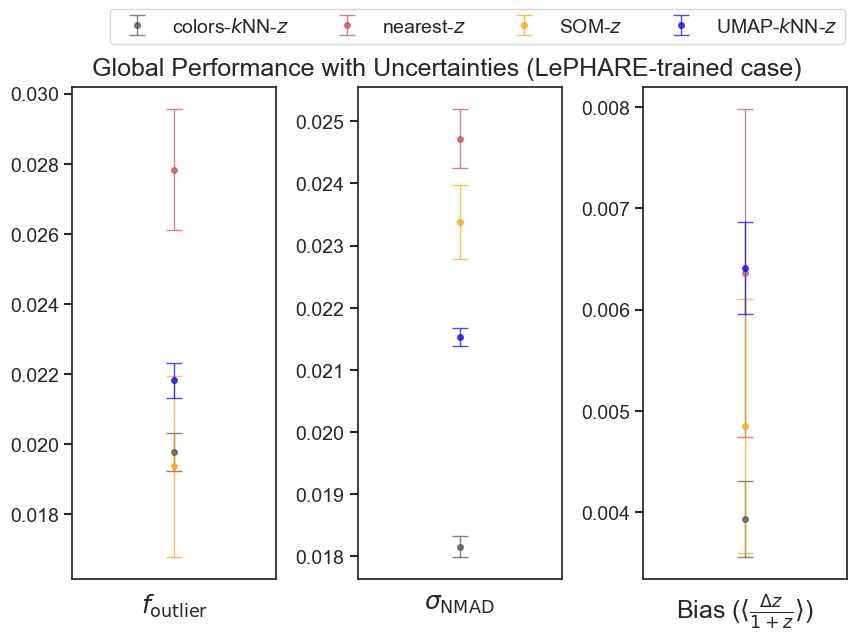

In [54]:
if 1:
    fig, axs = plt.subplots(1, 3, figsize=(10,6))

    results = global_results

    methods = ['colors', 'somrm', 'somtco', 'umap']
    method_labels = ['colors-'+r'$k$'+'NN-'+r'$z$', 'nearest-'+r'$z$', 'SOM-'+r'$z$', 'UMAP-'+r'$k$'+'NN-'+r'$z$']
    plot_cs = ['0.3', 'r', 'orange', 'blue']
    metrics = ['f_outlier', 'nmad', 'bias']
    metric_labels = [r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')']

    train = 'LePHARE'
    cs = 6
    vals = []
    uncs = []

    for ax in axs.flat:
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=14, length=6, width=1.5, 
                        bottom=False,top=False,left=True, right=False,
                        direction='out')
        
    #axs[0].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[2].yaxis.set_major_locator(MultipleLocator(0.005))

    for i, metric in enumerate(metrics):
        for j, method in enumerate(methods):
            if i ==0:
                axs[i].errorbar(metric_labels[i],results[train+'_trained'][metric][method+'_value'], 
                    yerr=results[train+'_trained'][metric][method+'_unc'], 
                    fmt='o', capsize=cs, lw=1, ms=4, c=plot_cs[j], alpha=0.7,
                    label=method_labels[j])
            else:
                axs[i].errorbar(metric_labels[i],results[train+'_trained'][metric][method+'_value'], 
                    yerr=results[train+'_trained'][metric][method+'_unc'], 
                    fmt='o', capsize=cs, lw=1, ms=4, c=plot_cs[j], alpha=0.7)
                
    fig.subplots_adjust(top=0.93, wspace=0.4)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=4, borderaxespad=0., fontsize=14)
    fig.suptitle('Global Performance with Uncertainties (LePHARE-trained case)', fontsize=18)

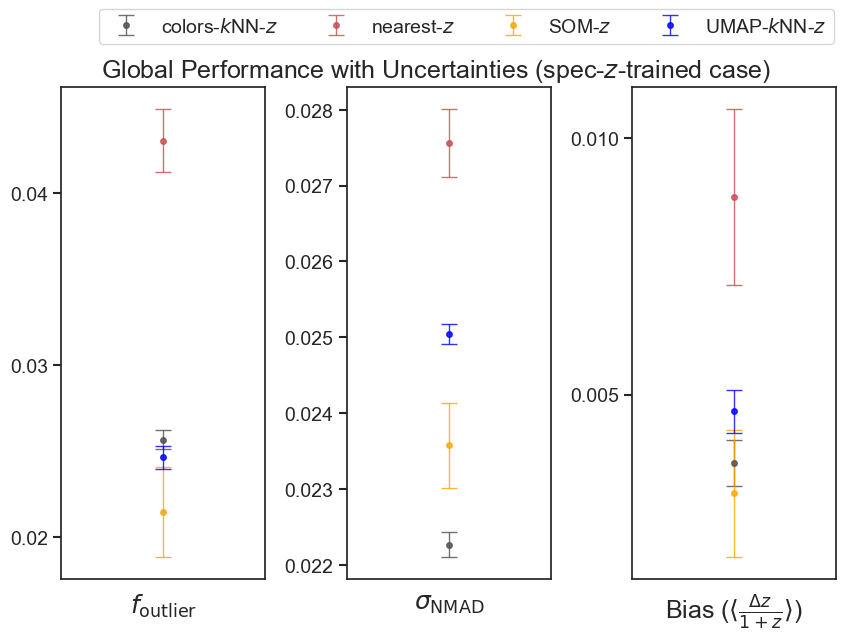

In [55]:
if 1:    
    fig, axs = plt.subplots(1, 3, figsize=(10,6))

    results = global_results

    methods = ['colors', 'somrm', 'somtco', 'umap']
    method_labels = ['colors-'+r'$k$'+'NN-'+r'$z$', 'nearest-'+r'$z$', 'SOM-'+r'$z$', 'UMAP-'+r'$k$'+'NN-'+r'$z$']
    plot_cs = ['0.3', 'r', 'orange', 'blue']
    metrics = ['f_outlier', 'nmad', 'bias']
    metric_labels = [r'$f_\mathrm{outlier}$', r'$\sigma_\mathrm{NMAD}$', 'Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')']

    train = 'specz'
    cs = 6
    vals = []
    uncs = []

    for ax in axs.flat:
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=14, length=6, width=1.5, 
                        bottom=False,top=False,left=True, right=False,
                        direction='out')
        
    axs[0].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[1].yaxis.set_major_locator(MultipleLocator(0.01))
    axs[2].yaxis.set_major_locator(MultipleLocator(0.005))

    for i, metric in enumerate(metrics):
        for j, method in enumerate(methods):
            if i ==0:
                axs[i].errorbar(metric_labels[i],results[train+'_trained'][metric][method+'_value'], 
                    yerr=results[train+'_trained'][metric][method+'_unc'], 
                    fmt='o', capsize=cs, lw=1, ms=4, c=plot_cs[j], alpha=0.8,
                    label=method_labels[j])
            else:
                axs[i].errorbar(metric_labels[i],results[train+'_trained'][metric][method+'_value'], 
                    yerr=results[train+'_trained'][metric][method+'_unc'], 
                    fmt='o', capsize=cs, lw=1, ms=4, c=plot_cs[j], alpha=0.8)
                
    fig.subplots_adjust(top=0.93, wspace=0.4)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=4, borderaxespad=0., fontsize=14)
    fig.suptitle('Global Performance with Uncertainties (spec-'+r'$z$'+'-trained case)', fontsize=18)

Text(0.5, 0.98, 'Global Performance with Uncertainties (spec-z-trained case)')

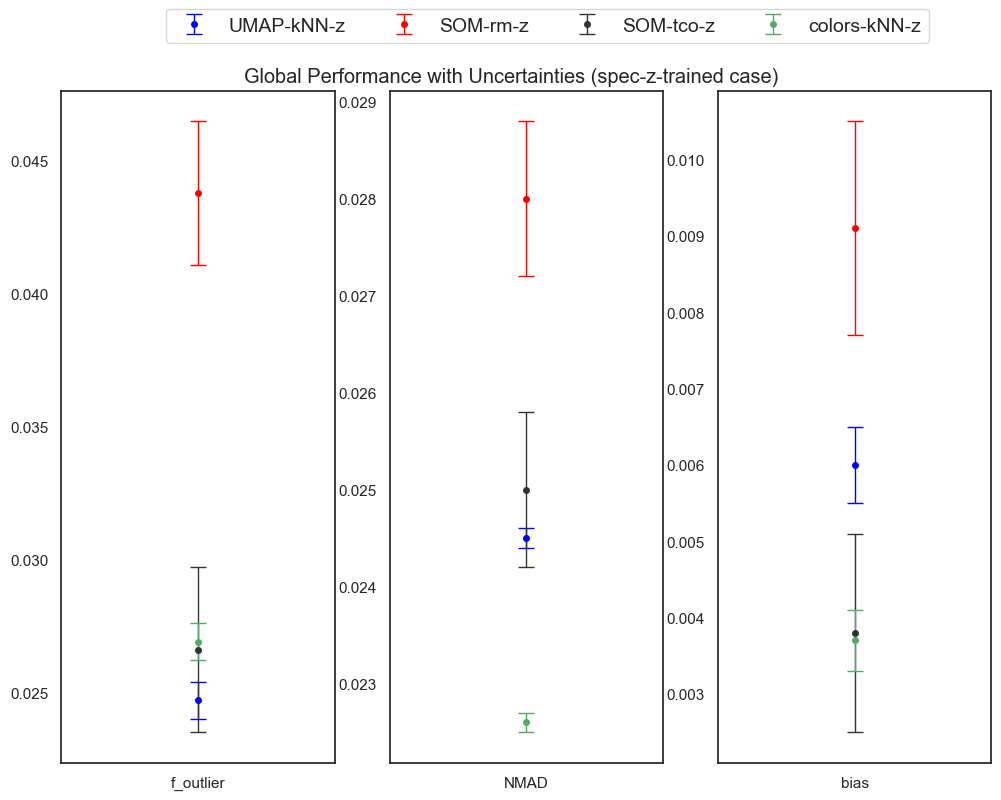

In [56]:
xs = ['f_outlier', 'NMAD', 'bias']
ys1 = [0.0247, 0.0245, 0.0060] # UMAP
yerrs1 = [0.0007, 0.0001, 0.0005]
ys2 = [0.0438, 0.028, 0.0091] # SOM-rm
yerrs2 = [0.0027, 0.0008, 0.0014]
ys3 = [0.0266, 0.025, 0.0038] # SOM-tco
yerrs3 = [0.0031, 0.0008, 0.0013]
ys4 = [0.0269, 0.0226, 0.0037] # colors
yerrs4 = [0.0007, 0.0001, 0.0004]

cs = 6
fig, axs = plt.subplots(1, 3, figsize=(12,8))
for i, x in enumerate(xs):
    if i ==0:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue', label='UMAP-kNN-z')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red', label='SOM-rm-z')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2', label='SOM-tco-z')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g', label='colors-kNN-z')
    else:
        axs[i].errorbar(x, ys1[i], yerr=yerrs1[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='blue')
        axs[i].errorbar(x, ys2[i], yerr=yerrs2[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='red')
        axs[i].errorbar(x, ys3[i], yerr=yerrs3[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='0.2')
        axs[i].errorbar(x, ys4[i], yerr=yerrs4[i], fmt='o', capsize=cs,
                            lw=1, ms=4, c='g')

#fig.legend(bbox_to_anchor=(0.9,0.88), fontsize=14)
fig.subplots_adjust(top=0.95)
fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                    ncols=4, borderaxespad=0., fontsize=14)
fig.suptitle('Global Performance with Uncertainties (spec-z-trained case)')